In [ ]:
"""
Combines *_category_tests.csv files into a DataFrame loadable from this notebook.
"""

import re
from pathlib import Path

import pandas as pd

UNPREFIXED_NAME = re.compile(r"^q\d+_.*__category_tests\.csv$")


def combine_significance(root_dir: Path, output_dir: Path, write_files: bool = False):
    all_files = sorted(root_dir.glob("significance_*/*category_tests*.csv"))

    if not all_files:
        all_files = sorted(root_dir.rglob("*category_tests*.csv"))

    files = [f for f in all_files if UNPREFIXED_NAME.match(f.name)]

    skipped = [f for f in all_files if f not in files]
    if skipped:
        print(f"Skipped {len(skipped)} files with a model prefix (not combined):")
        for f in skipped:
            print(f"  - {f}")

    if not files:
        print(f"No unprefixed *category_tests*.csv found inside {root_dir}")
        return pd.DataFrame(), pd.DataFrame()

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["source_folder"] = f.parent.name
        dfs.append(df)
        print(f"Read: {f}  ({len(df)} rows)")

    combined = pd.concat(dfs, ignore_index=True)

    key_cols = ["question_key", "model_alias", "attribute", "category_value", "group_value"]
    before = len(combined)
    combined = combined.drop_duplicates(subset=key_cols, keep="first")
    if len(combined) < before:
        print(f"Removed {before - len(combined)} duplicate rows (files repeated with/without prefix).")

    combined["significant"] = combined["reject_fdr"].map({True: "Yes", False: "No"})

    combined = combined.sort_values(
        ["model_alias", "question_key", "attribute", "category_value", "group_value"]
    ).reset_index(drop=True)

    summary = (
        combined.groupby(["model_alias", "question_key", "attribute"])["reject_fdr"]
        .agg(total_tests="count", significant="sum")
        .reset_index()
    )

    if write_files:
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / "combined_category_tests.csv"
        combined.to_csv(out_path, index=False)
        summary_path = output_dir / "significance_summary.csv"
        summary.to_csv(summary_path, index=False)
        print(f"Saved CSVs to: {output_dir}")

    return combined, summary

root_dir = Path("../results_merged/frequency_tables")
output_dir = Path("combined_significance")
combined_df, summary_df = combine_significance(root_dir, output_dir, write_files=False)

n_before = len(combined_df)
combined_df = combined_df[combined_df["model_alias"] != "all_models"].reset_index(drop=True)
print(f"Excluded {n_before - len(combined_df)} rows from 'all_models' (pooled test, not a model).")
print(f"Combined in-memory: {len(combined_df)} rows")


Read: ..\results_merged\frequency_tables\significance_tests\all_models\q1_gender__category_tests.csv  (70 rows)
Read: ..\results_merged\frequency_tables\significance_tests\all_models\q1_race__category_tests.csv  (280 rows)
Read: ..\results_merged\frequency_tables\significance_tests\all_models\q2_gender__category_tests.csv  (42 rows)
Read: ..\results_merged\frequency_tables\significance_tests\all_models\q2_race__category_tests.csv  (168 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q1_gender__category_tests.csv  (62 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q1_race__category_tests.csv  (248 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q2_gender__category_tests.csv  (38 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q2_race__category_tests.csv  (152 rows)
Read: ..\results_merged\frequency_tables\significance_tests\

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("figures")                
TOP_N = 10                                 

QUESTION_TITLES = {
    "q1": "Job Recommendation",
    "q2": "College Recommendation",
}

MODEL_COLORS = {
    "deepseek-v4-flash_paid": "#7b3fa0",
    "gemma-4-31b_paid": "#1b9e77",
    "glm-5.2_paid": "#e6ab02",
    "grok-4.3_paid": "#d94b4b",
    "gemma-4-e2b_modal": "#377eb8",
    "ministral-3-8b_modal": "#a6761d",
}
FALLBACK_COLORS = plt.cm.tab10.colors

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = combined_df.copy()

print(f"{len(df)} rows")
print("Models:", df["model_alias"].unique())
print("Questions:", df["question_key"].unique())
print("Attributes:", df["attribute"].unique())
df.head()

2840 rows
Models: ['deepseek-v4-flash_paid' 'gemma-4-31b_paid' 'gemma-4-e2b_modal'
 'glm-5.2_paid' 'grok-4.3_paid' 'ministral-3-8b_modal']
Questions: ['q1' 'q2']
Attributes: ['Gender' 'Race']


,question_key,model_alias,attribute,category_value,group_value,group_in_category,group_outside_category,other_in_category,other_outside_category,group_total,...,category_total,non_category_total,odds_ratio,p_value,corrected_p_value,reject_fdr,statistic,test_name,source_folder,significant
0,q1,deepseek-v4-flash_paid,Gender,Administrative and commercial managers,Female,15,1962,9,1667,1977,...,24,3629,1.416072,5.385032e-01,6.182815e-01,False,NaN,fisher_exact_2x2,deepseek-v4-flash_paid,No
1,q1,deepseek-v4-flash_paid,Gender,Administrative and commercial managers,Male,9,1667,15,1962,1676,...,24,3629,0.706179,5.385032e-01,6.182815e-01,False,NaN,fisher_exact_2x2,deepseek-v4-flash_paid,No
2,q1,deepseek-v4-flash_paid,Gender,"Armed forces occupations, other ranks",Female,0,1977,84,1592,1977,...,84,3569,0.000000,1.189546e-29,5.267988e-29,True,NaN,fisher_exact_2x2,deepseek-v4-flash_paid,Yes
3,q1,deepseek-v4-flash_paid,Gender,"Armed forces occupations, other ranks",Male,84,1592,0,1977,1676,...,84,3569,inf,1.189546e-29,5.267988e-29,True,NaN,fisher_exact_2x2,deepseek-v4-flash_paid,Yes
4,q1,deepseek-v4-flash_paid,Gender,Building and related trades workers,Female,0,1977,31,1645,1977,...,31,3622,0.000000,2.783303e-11,6.163029e-11,True,NaN,fisher_exact_2x2,deepseek-v4-flash_paid,Yes


In [ ]:
def clean_model(name: str) -> str:
    return name.replace("_paid", "").replace("_modal", "")


def prepare_gender_data(df: pd.DataFrame, question: str) -> pd.DataFrame:
    """Pivots Female/Male by (model, category) and computes the gap and log2(OR) Female vs Male."""
    sub = df[(df["question_key"] == question) & (df["attribute"] == "Gender")].copy()
    if sub.empty:
        return sub

    fem = sub[sub["group_value"] == "Female"].set_index(["model_alias", "category_value"])
    mal = sub[sub["group_value"] == "Male"].set_index(["model_alias", "category_value"])

    idx = fem.index.intersection(mal.index)
    out = pd.DataFrame(index=idx)
    out["f_in"] = fem.loc[idx, "group_in_category"]
    out["f_out"] = fem.loc[idx, "group_outside_category"]
    out["m_in"] = mal.loc[idx, "group_in_category"]
    out["m_out"] = mal.loc[idx, "group_outside_category"]
    out["category_total"] = fem.loc[idx, "category_total"]

    denom = (out["f_in"] + out["m_in"]).replace(0, np.nan)
    out["gap_pct"] = (out["f_in"] - out["m_in"]) / denom * 100

    # log2 odds ratio Female vs Male, Haldane correction (+0.5)
    a, b = out["f_in"] + 0.5, out["f_out"] + 0.5
    c, d = out["m_in"] + 0.5, out["m_out"] + 0.5
    out["log2_or"] = np.log2((a / b) / (c / d))

    out["significant"] = fem.loc[idx, "reject_fdr"].astype(bool)

    return out.reset_index()

In [ ]:
from matplotlib.lines import Line2D

def dot_panel(ax, data, categories, models, x_col, xlabel, footnote):
    n_models = len(models)
    total_span = 0.45   
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]
            sig = bool(row["significant"])
            ax.plot(
                row[x_col], y,
                marker="o", linestyle="none", markersize=7,
                markerfacecolor=color if sig else "none",
                markeredgecolor=color, markeredgewidth=1.6,
                zorder=3,
            )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, zorder=2)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(list(reversed(categories)), fontsize=9)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(axis="x", color="0.85", zorder=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.annotate(footnote, xy=(0.5, -0.13), xycoords="axes fraction",
                ha="center", fontsize=8, style="italic")

def make_figure(df: pd.DataFrame, question: str):
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    top_cats = (
        data.groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )
    data = data[data["category_value"].isin(top_cats)]
    models = sorted(data["model_alias"].unique())
    title = QUESTION_TITLES.get(question, question)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    dot_panel(axes[0], data, top_cats, models, "gap_pct",
              "Female − Male share (%)",
              "left = Male-skewed   ·   right = Female-skewed")
    axes[0].set_title(f"{title} - Gender gap by field, across models",
                      fontsize=11, fontweight="bold")

    dot_panel(axes[1], data, top_cats, models, "log2_or",
              "log2(Odds Ratio) [Female vs Male]",
              "left = Male-skewed (OR<1)   ·   right = Female-skewed (OR>1)")
    axes[1].set_title(f"{title} - Gender odds ratio by field, across models",
                      fontsize=11, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    axes[1].legend(handles=handles, title="Model", loc="center left",
                   bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9)

    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    out = OUTPUT_DIR / f"gender_dotplot_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()  

for q in sorted(df["question_key"].unique()):
    make_figure(df, q) 

Saved: figures\gender_oddsratio_q1_job_recommendation.png


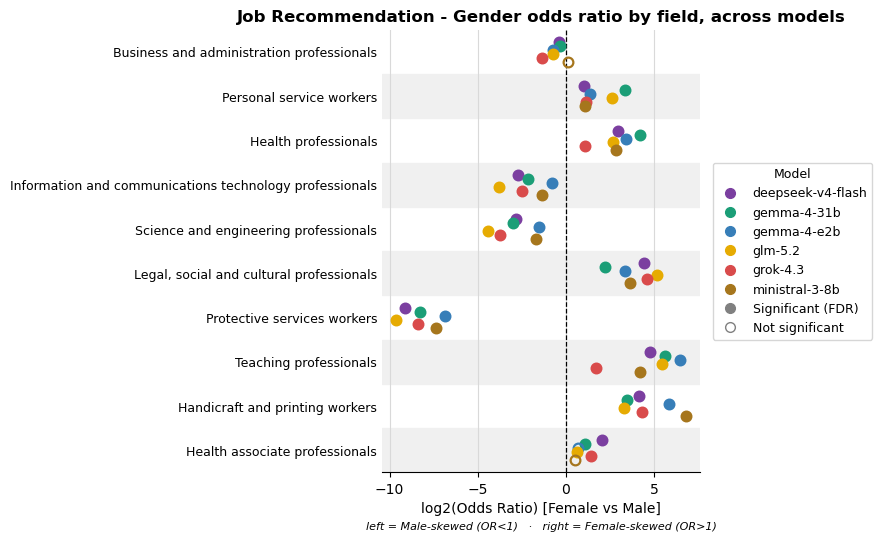

Saved: figures\gender_oddsratio_q2_college_recommendation.png


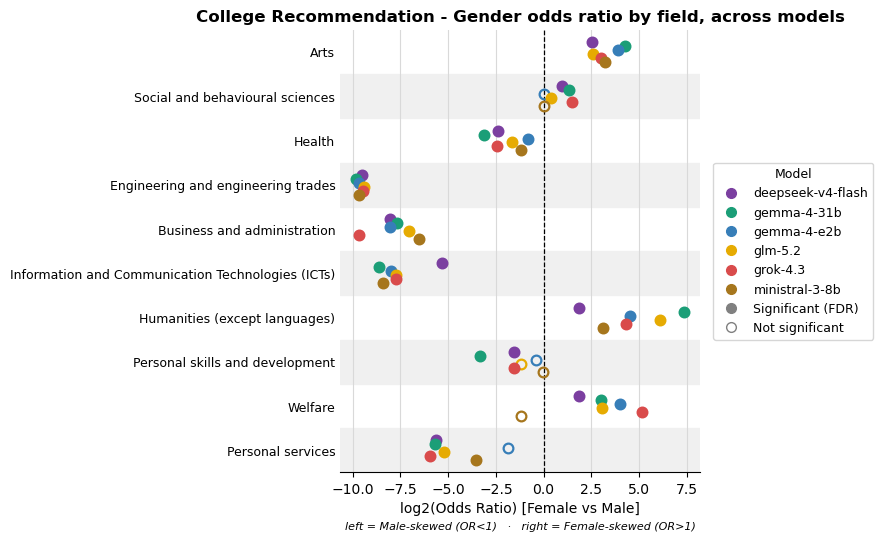

In [ ]:
def make_or_figure(df: pd.DataFrame, question: str):
    """Generates ONLY the log2(Odds Ratio) plot for one question."""
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    models = sorted(data["model_alias"].unique())

    # Only categories present in ALL models
    counts = data.groupby("category_value")["model_alias"].nunique()
    shared_cats = counts[counts == len(models)].index

    top_cats = (
        data[data["category_value"].isin(shared_cats)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )
    data = data[data["category_value"].isin(top_cats)]

    title = QUESTION_TITLES.get(question, question)

    fig, ax = plt.subplots(figsize=(9, 5.5))

    dot_panel(ax, data, top_cats, models, "log2_or",
              "log2(Odds Ratio) [Female vs Male]",
              "left = Male-skewed (OR<1)   ·   right = Female-skewed (OR>1)")
    ax.set_title(f"{title} - Gender odds ratio by field, across models",
                 fontsize=12, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    ax.legend(handles=handles, title="Model", loc="center left",
              bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9)

    fig.tight_layout()
    out = OUTPUT_DIR / f"gender_oddsratio_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

for q in sorted(df["question_key"].unique()):
    make_or_figure(df, q)

Saved: figures\acm_gender_oddsratio_q1_job_recommendation.png


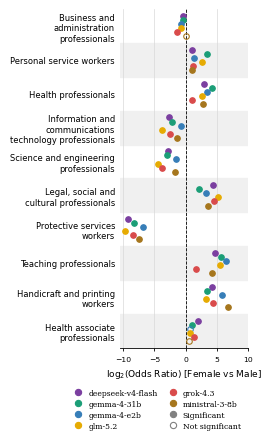

Saved: figures\acm_gender_oddsratio_q2_college_recommendation.png


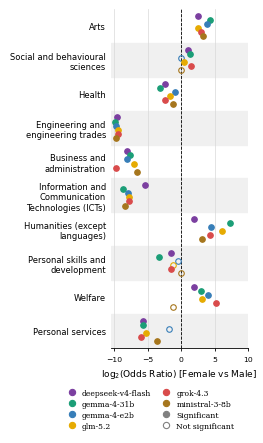

In [ ]:
import textwrap

ACM_COLUMN_WIDTH_IN = 2.5   
ACM_LABEL_WRAP = 24         
ACM_XLIM = (-10.5, 10)      
ACM_LEGEND_X = 0.28         

def dot_panel_acm(ax, data, categories, models, x_col, xlim=None):
    """Compact version of dot_panel: small markers/text, for a single column."""
    n_models = len(models)
    total_span = 0.6
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]
            sig = bool(row["significant"])
            ax.plot(
                row[x_col], y,
                marker="o", linestyle="none", markersize=4,
                markerfacecolor=color if sig else "none",
                markeredgecolor=color, markeredgewidth=0.8,
                zorder=3,
            )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.6, zorder=2)
    ax.set_yticks(range(len(categories)))
    wrapped = [textwrap.fill(c, ACM_LABEL_WRAP) for c in reversed(categories)]
    ax.set_yticklabels(wrapped, fontsize=6)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.set_xlabel("log$_2$(Odds Ratio) [Female vs Male]", fontsize=6.5)
    ax.tick_params(axis="x", labelsize=5.5, width=0.6, length=2.5)
    ax.grid(axis="x", color="0.85", zorder=1, linewidth=0.5)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    for spine in ["bottom"]:
        ax.spines[spine].set_linewidth(0.6)
    ax.tick_params(axis="y", length=0)


def make_or_figure_acm(df: pd.DataFrame, question: str, top_n: int = TOP_N):
    """Log2(Odds Ratio) by gender, formatted for a single column of the ACM sigconf template.

    Saves PNG only (600dpi). The vector PDF is deliberately NOT generated here.
    """
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    models = sorted(data["model_alias"].unique())

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared_cats = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared_cats)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(top_n).index.tolist()
    )
    data = data[data["category_value"].isin(top_cats)]

    title = QUESTION_TITLES.get(question, question)

    row_h = 0.30
    height = row_h * len(top_cats) + 1.3  
    fig, ax = plt.subplots(figsize=(ACM_COLUMN_WIDTH_IN, height))

    with plt.rc_context({"font.family": "serif"}):
        dot_panel_acm(ax, data, top_cats, models, "log2_or", xlim=ACM_XLIM)

        handles = [
            Line2D([], [], marker="o", linestyle="none", markersize=4.5,
                   markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgewidth=0.8, label=clean_model(m))
            for i, m in enumerate(models)
        ]
        handles += [
            Line2D([], [], marker="o", linestyle="none", markersize=4.5,
                   markerfacecolor="gray", markeredgecolor="gray", markeredgewidth=0.8,
                   label="Significant"),
            Line2D([], [], marker="o", linestyle="none", markersize=4.5,
                   markerfacecolor="none", markeredgecolor="gray", markeredgewidth=0.8,
                   label="Not significant"),
        ]
        ax.legend(
            handles=handles, loc="upper center", bbox_to_anchor=(ACM_LEGEND_X, -0.11),
            ncol=2, fontsize=5.5, frameon=False, handletextpad=0.3,
            columnspacing=1.0, labelspacing=0.4, borderaxespad=0.1,
        )

    fig.tight_layout(pad=0.25)
    stem = f"acm_gender_oddsratio_{question}_{title.lower().replace(' ', '_')}"
    out_png = OUTPUT_DIR / f"{stem}.png"
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.show()


for q in sorted(df["question_key"].unique()):
    make_or_figure_acm(df, q)


Saved: figures\acm_gender_oddsratio_combined.png


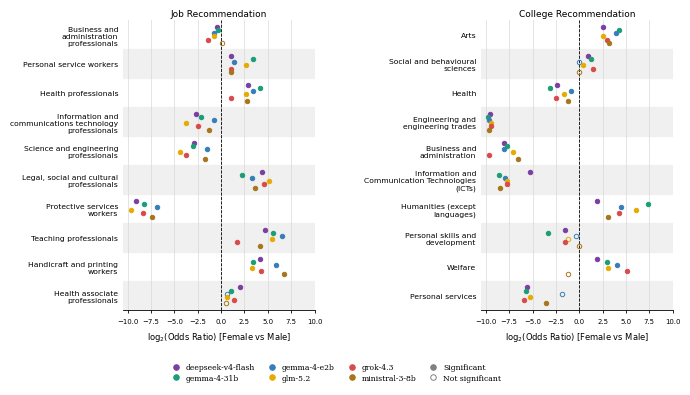

In [ ]:
import textwrap
from matplotlib.lines import Line2D
 
ACM_TEXT_WIDTH_IN = 7.0
ACM_LABEL_WRAP = 26         
ACM_XLIM = (-10.5, 10)
ROW_H = 0.28                
PANEL_SHRINK = 0.90         
FS_YLABEL = 5.5
FS_XTICK = 5.0
FS_XLABEL = 6.0
FS_TITLE = 6.5
FS_LEGEND = 5.5
 
 
def dot_panel_acm_wide(ax, data, categories, models, x_col, xlim=None):
    n_models = len(models)
    total_span = 0.55
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]
 
    y_base = {cat: i for i, cat in enumerate(reversed(categories))}
 
    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)
 
    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]
            sig = bool(row["significant"])
            ax.plot(
                row[x_col], y,
                marker="o", linestyle="none", markersize=3.2,
                markerfacecolor=color if sig else "none",
                markeredgecolor=color, markeredgewidth=0.7,
                zorder=3,
            )
 
    ax.axvline(0, color="black", linestyle="--", linewidth=0.6, zorder=2)
    ax.set_yticks(range(len(categories)))
    wrapped = [textwrap.fill(c, ACM_LABEL_WRAP) for c in reversed(categories)]
    ax.set_yticklabels(wrapped, fontsize=FS_YLABEL)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.set_xlabel("log$_2$(Odds Ratio) [Female vs Male]", fontsize=FS_XLABEL)
    ax.tick_params(axis="x", labelsize=FS_XTICK, width=0.6, length=2.5)
    ax.grid(axis="x", color="0.85", zorder=1, linewidth=0.5)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(axis="y", length=0)
 
 
def make_or_figure_acm_combined(df: pd.DataFrame, top_n: int = TOP_N):
    questions = sorted(df["question_key"].unique())  # -> ["q1", "q2"]
 
    panels = []
    all_models = set()
    for q in questions:
        data = prepare_gender_data(df, q)
        if data.empty:
            print(f"[!] No Gender data for {q}, skipping combined figure.")
            return
        models = sorted(data["model_alias"].unique())
        all_models.update(models)
 
        counts = data.groupby("category_value")["model_alias"].nunique()
        shared_cats = counts[counts == len(models)].index
        top_cats = (
            data[data["category_value"].isin(shared_cats)]
            .groupby("category_value")["category_total"].sum()
            .sort_values(ascending=False).head(top_n).index.tolist()
        )
        panels.append((q, data[data["category_value"].isin(top_cats)], top_cats, models))
 
    models_all = sorted(all_models)
 
    n_rows = max(len(p[2]) for p in panels)
    height = ROW_H * n_rows + 1.0
    fig, axes = plt.subplots(1, 2, figsize=(ACM_TEXT_WIDTH_IN, height))
 
    with plt.rc_context({"font.family": "serif"}):
        for ax, (q, data, cats, models) in zip(axes, panels):
            dot_panel_acm_wide(ax, data, cats, models, "log2_or", xlim=ACM_XLIM)
            ax.set_title(QUESTION_TITLES.get(q, q), fontsize=FS_TITLE, pad=3)
 
        handles = [
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
                   markeredgewidth=0.7, label=clean_model(m))
            for i, m in enumerate(models_all)
        ]
        handles += [
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor="gray", markeredgecolor="gray",
                   markeredgewidth=0.7, label="Significant"),
            Line2D([], [], marker="o", linestyle="none", markersize=4,
                   markerfacecolor="none", markeredgecolor="gray",
                   markeredgewidth=0.7, label="Not significant"),
        ]
        fig.legend(
            handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.0),
            ncol=4, fontsize=FS_LEGEND, frameon=False,
            handletextpad=0.3, columnspacing=1.2, labelspacing=0.3,
            borderaxespad=0.0,
        )
 
    fig.tight_layout(pad=0.3, w_pad=1.5, rect=(0, 0.10, 1, 1))
 
    # --- equalize panel widths AND shrink them to leave more room for labels ---
    p0, p1 = axes[0].get_position(), axes[1].get_position()
    w = min(p0.width, p1.width) * PANEL_SHRINK
    axes[0].set_position([p0.x1 - w, p0.y0, w, p0.height])
    axes[1].set_position([p1.x1 - w, p1.y0, w, p1.height])
 
    out_png = OUTPUT_DIR / "acm_gender_oddsratio_combined.png"
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.show()
 
 
make_or_figure_acm_combined(df)

q1: 29 model×category combinations with no data (marked with X)
Saved: figures\gender_oddsratio_ALL_q1_job_recommendation.png  (35 categories)


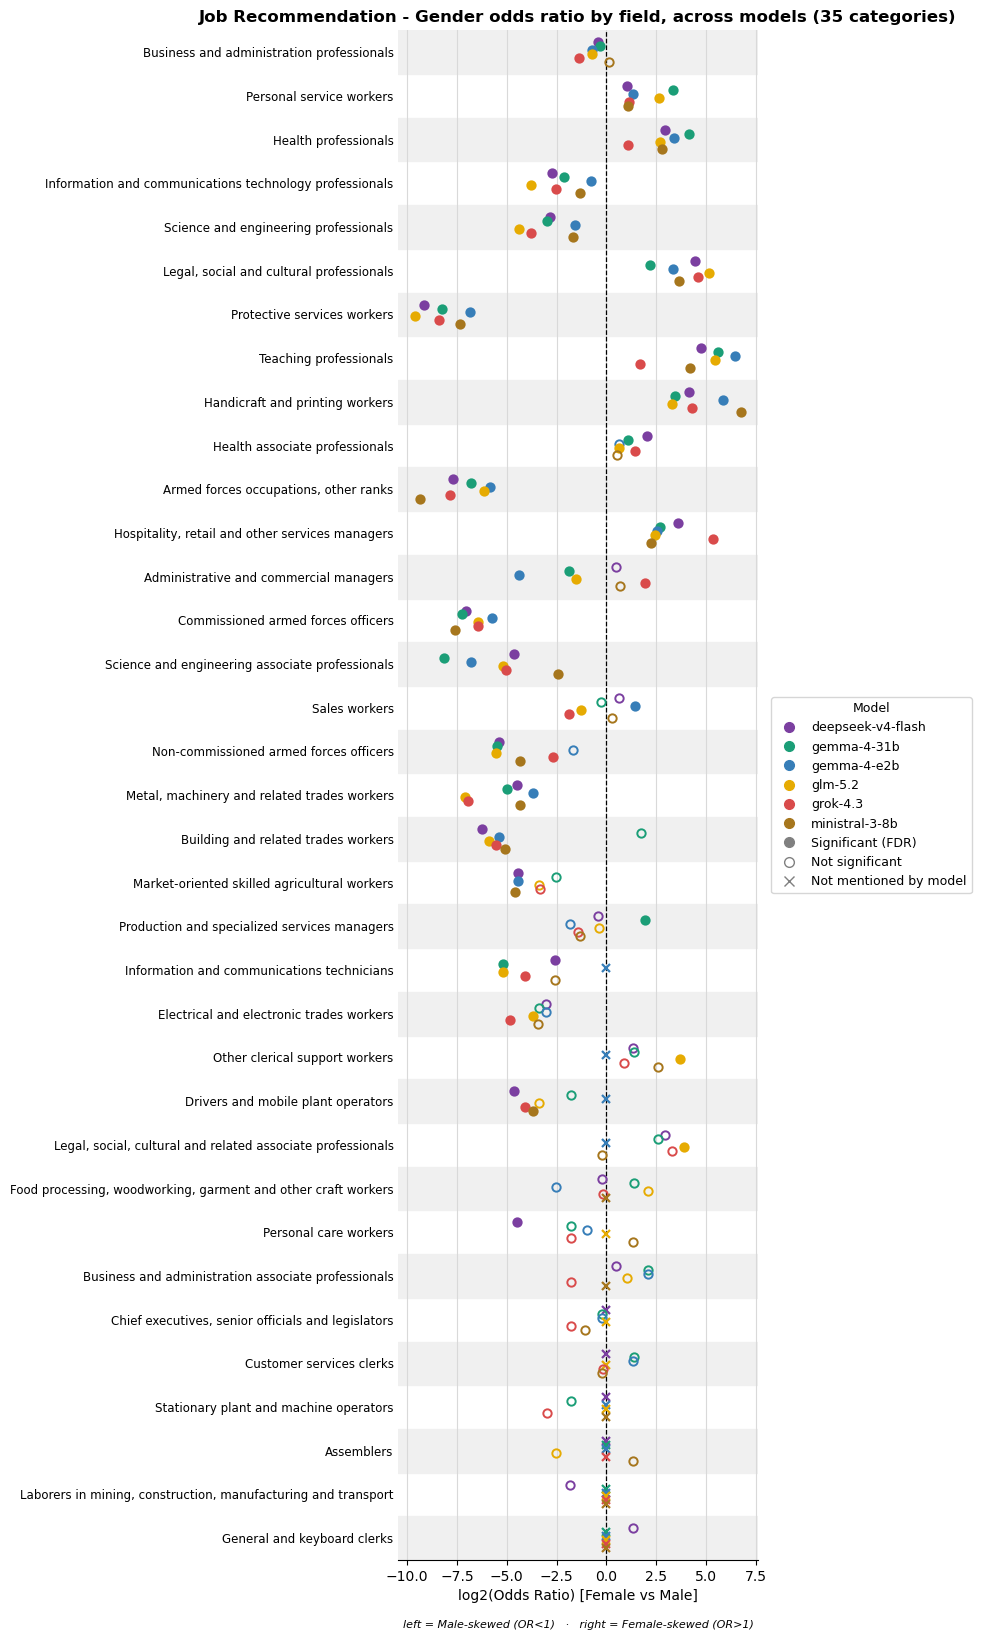

q2: 23 model×category combinations with no data (marked with X)
Saved: figures\gender_oddsratio_ALL_q2_college_recommendation.png  (21 categories)


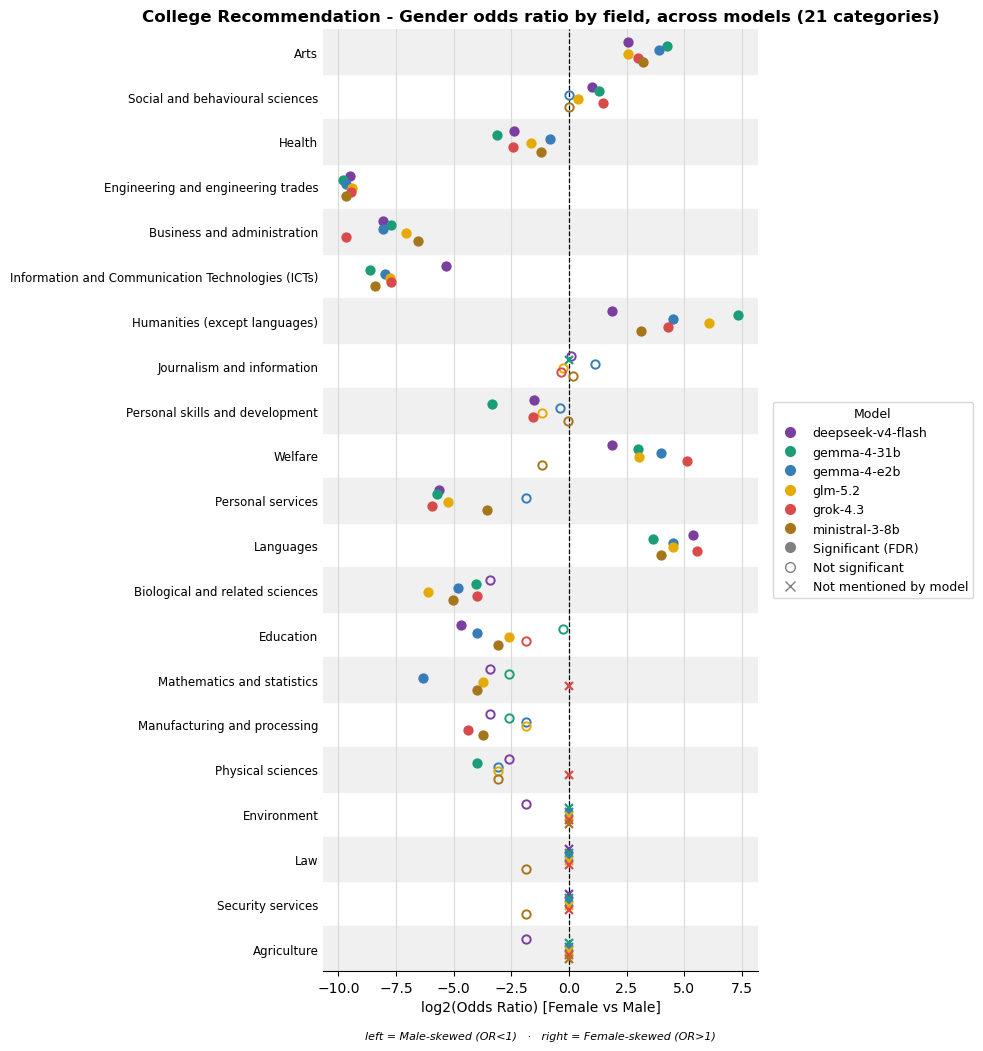

In [ ]:
def dot_panel_all(ax, data, categories, models, x_col, xlabel, footnote):
    n_models = len(models)
    total_span = 0.45
    offsets = np.linspace(total_span / 2, -total_span / 2, n_models) if n_models > 1 else [0.0]

    y_base = {cat: i for i, cat in enumerate(reversed(categories))}

    for i in range(len(categories)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

    for mi, model in enumerate(models):
        color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
        mdata = data[data["model_alias"] == model]
        for _, row in mdata.iterrows():
            if row["category_value"] not in y_base:
                continue
            y = y_base[row["category_value"]] + offsets[mi]

            if row.get("missing", False):
                ax.plot(0.0, y, marker="x", linestyle="none",
                        markersize=6, markeredgecolor=color,
                        markeredgewidth=1.6, zorder=3)
            else:
                sig = bool(row["significant"])
                ax.plot(row[x_col], y, marker="o", linestyle="none",
                        markersize=6,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.4,
                        zorder=3)

    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, zorder=2)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(list(reversed(categories)), fontsize=8.5)
    ax.set_ylim(-0.5, len(categories) - 0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(axis="x", color="0.85", zorder=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="y", length=0)

    ax.annotate(footnote,
                xy=(0.5, 0), xycoords=ax.xaxis.label,
                xytext=(0, -12), textcoords="offset points",
                ha="center", va="top", fontsize=8, style="italic")


def make_or_figure_all(df: pd.DataFrame, question: str):
    """log2(Odds Ratio) plot with ALL categories; models missing a category are marked with an X."""
    data = prepare_gender_data(df, question)
    if data.empty:
        print(f"[!] No Gender data for {question}, skipping.")
        return

    models = sorted(data["model_alias"].unique())

    cats = (
        data.groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).index.tolist()
    )

    data["missing"] = False
    existing = set(zip(data["model_alias"], data["category_value"]))
    missing = [
        {"model_alias": m, "category_value": c, "log2_or": 0.0,
         "significant": False, "missing": True}
        for m in models for c in cats if (m, c) not in existing
    ]
    if missing:
        data = pd.concat([data, pd.DataFrame(missing)], ignore_index=True)
        print(f"{question}: {len(missing)} model×category combinations with no data (marked with X)")

    title = QUESTION_TITLES.get(question, question)

    height = max(5.0, 0.42 * len(cats) + 1.8)
    fig, ax = plt.subplots(figsize=(10, height))

    dot_panel_all(ax, data, cats, models, "log2_or",
                  "log2(Odds Ratio) [Female vs Male]",
                  "left = Male-skewed (OR<1)   ·   right = Female-skewed (OR>1)")
    ax.set_title(f"{title} - Gender odds ratio by field, across models ({len(cats)} categories)",
                 fontsize=12, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
        Line2D([], [], marker="x", linestyle="none", markersize=7,
               markeredgecolor="gray", label="Not mentioned by model"),
    ]
    ax.legend(handles=handles, title="Model", loc="center left",
              bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9)

    fig.tight_layout()
    out = OUTPUT_DIR / f"gender_oddsratio_ALL_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}  ({len(cats)} categories)")
    plt.show()


for q in sorted(df["question_key"].unique()):
    make_or_figure_all(df, q)